# 03 - Embeddings Comparison: Choosing the Right Embedding Model

**Phase 3** of the RAG exploration project. We compare 4 open-source embedding models
that run 100% locally:

1. **all-MiniLM-L6-v2** (sentence-transformers) - 384 dim, ~80MB, fastest
2. **nomic-embed-text** (Ollama) - 768 dim, ~275MB, Ollama-native
3. **BAAI/bge-small-en-v1.5** (sentence-transformers) - 384 dim, ~130MB, strong MTEB
4. **mxbai-embed-large** (Ollama) - 1024 dim, ~670MB, highest quality

For each model we measure:
- **Embedding throughput**: time to embed the full corpus
- **Query latency**: average time to embed a single query
- **Memory / disk usage**: vector store size on disk
- **Retrieval quality**: top score, avg score on benchmark queries
- **Semantic sanity checks**: known-similar and known-dissimilar pairs

We use the **recursive** chunking strategy (chunk_size=1000, overlap=200) from Phase 2
as our fixed corpus.

---

## 0. Setup

In [7]:
import json
import os
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.loaders import load_scraped_documents
from src.ingestion.cleaners import clean_corpus
from src.ingestion.chunkers import chunk_recursive
from src.embeddings.models import (
    create_from_registry,
    benchmark_embedding,
    load_model_registry,
    EmbeddingModelInfo,
    filter_chunks_by_max_chars,
    get_strictest_max_chars,
)
from notebooks.utils.display import display_retrieval_results
from notebooks.utils.metrics import benchmark_queries

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

MODELS_YAML = str(PROJECT_ROOT / "configs" / "models.yaml")

print(f"Project root: {PROJECT_ROOT}")

Project root: D:\Astyan\rag-exploration


## 1. Prepare the Corpus

Load, clean, and chunk with recursive splitting (the Phase 2 baseline).

We then filter out chunks that exceed the context window of the most restrictive model.
The filter uses `max_chars` from `configs/models.yaml` as a first pass, then validates
with the actual model to catch edge cases (CJK characters tokenize into more tokens per
character). This ensures **all models are benchmarked on exactly the same texts**.

In [8]:
docs = load_scraped_documents(str(PROJECT_ROOT / "data" / "raw" / "langchain_docs.json"))
cleaned_docs, clean_stats = clean_corpus(docs, min_content_length=50)

result = chunk_recursive(cleaned_docs, chunk_size=1000, chunk_overlap=200)
all_chunks = result.chunks
print(f"Loaded: {len(docs)} docs -> Cleaned: {len(cleaned_docs)} -> Chunks: {len(all_chunks)}")

# First pass: filter by max_chars from the registry
registry = load_model_registry(MODELS_YAML)
MAX_CHARS = get_strictest_max_chars(list(registry.values()))

print(f"\nModel context limits (max_chars):")
for key, info in registry.items():
    marker = " <- strictest" if info.max_chars == MAX_CHARS else ""
    print(f"  {key:15s}: {info.max_chars:>6} chars ({info.max_tokens} tokens){marker}")

chunks, dropped_chars = filter_chunks_by_max_chars(all_chunks, max_chars=MAX_CHARS)
print(f"\nAfter char filter (max_chars={MAX_CHARS}): {len(chunks)} chunks (dropped {dropped_chars})")

# Second pass: validate "suspect" chunks (high non-ASCII ratio) with mxbai-embed-large.
# CJK characters tokenize into 2-3 tokens each, so a 1000-char chunk with lots of
# CJK can exceed the 512-token context window despite being under 1400 chars.
# We only test suspects (>5% non-ASCII) to keep this fast (~few seconds).
from langchain_ollama import OllamaEmbeddings

_validator = OllamaEmbeddings(model="mxbai-embed-large")

valid_chunks = []
token_dropped = 0
suspects_tested = 0

for c in chunks:
    text = c.page_content
    non_ascii_ratio = sum(1 for ch in text if ord(ch) > 127) / len(text) if text else 0

    if non_ascii_ratio > 0.05:
        suspects_tested += 1
        try:
            _validator.embed_documents([text])
            valid_chunks.append(c)
        except Exception:
            token_dropped += 1
    else:
        valid_chunks.append(c)

del _validator  # free memory

print(f"Validation pass: tested {suspects_tested} suspect chunks (>5% non-ASCII), dropped {token_dropped}")

chunks = valid_chunks
corpus_texts = [c.page_content for c in chunks]

print(f"\nFinal corpus: {len(chunks)} chunks, {sum(len(t) for t in corpus_texts):,} characters total")

Loaded 1463 documents from D:\Astyan\rag-exploration\data\raw\langchain_docs.json
Loaded: 1463 docs -> Cleaned: 1445 -> Chunks: 15592

Model context limits (max_chars):
  nomic_embed    :  24000 chars (8192 tokens)
  minilm         :   1400 chars (256 tokens) <- strictest
  bge_small      :   1400 chars (512 tokens) <- strictest
  mxbai_large    :   1400 chars (512 tokens) <- strictest

After char filter (max_chars=1400): 15592 chunks (dropped 0)
Validation pass: tested 69 suspect chunks (>5% non-ASCII), dropped 15

Final corpus: 15577 chunks, 12,248,603 characters total


---
## 2. Load All Embedding Models

We use the model registry (`configs/models.yaml`) to instantiate each model.

> **Note**: Ollama models (`nomic-embed-text`, `mxbai-embed-large`) require `ollama serve` running.
> Sentence-transformers models are downloaded automatically on first use.

In [9]:
MODEL_KEYS = ["minilm", "nomic_embed", "bge_small", "mxbai_large"]

models = {}
for key in MODEL_KEYS:
    print(f"Loading {key}...", end=" ", flush=True)
    try:
        emb, info = create_from_registry(key, config_path=MODELS_YAML)
        # Warmup: embed one short text to trigger model loading / download
        emb.embed_query("warmup")
        models[key] = {"embeddings": emb, "info": info}
        print(f"OK ({info.provider}, {info.dimensions}d, max_chars={info.max_chars})")
    except Exception as e:
        print(f"FAILED: {e}")

print(f"\n{len(models)}/{len(MODEL_KEYS)} models loaded successfully.")

Loading minilm... 

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1380.87it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


OK (sentence-transformers, 384d, max_chars=1400)
Loading nomic_embed... OK (ollama, 768d, max_chars=24000)
Loading bge_small... 

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1610.84it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


OK (sentence-transformers, 384d, max_chars=1400)
Loading mxbai_large... OK (ollama, 1024d, max_chars=1400)

4/4 models loaded successfully.


---
## 3. Embedding Throughput Benchmark

We embed a **sample** of the corpus (500 chunks) and measure total time and per-query latency.
Full corpus embedding is done later during indexing (section 5).

In [10]:
import random

random.seed(42)
SAMPLE_SIZE = 500
sample_texts = random.sample(corpus_texts, min(SAMPLE_SIZE, len(corpus_texts)))

BENCH_QUERIES = [
    "How do I create a basic RAG chain in LangChain?",
    "What is an Embedding model?",
    "How does RecursiveCharacterTextSplitter work?",
    "What are the different types of memory in LangChain?",
    "How do I use Ollama with LangChain?",
]

benchmarks = {}

for key, m in models.items():
    print(f"Benchmarking {key} ({len(sample_texts)} texts, {len(BENCH_QUERIES)} queries)...", flush=True)
    bench = benchmark_embedding(
        m["embeddings"],
        sample_texts,
        BENCH_QUERIES,
        model_name=key,
    )
    benchmarks[key] = bench
    print(f"  Corpus: {bench.embed_corpus_time_s:.1f}s | Avg query: {bench.avg_query_latency_ms:.1f}ms")
    print(f"  Embedded: {bench.num_documents}/{len(sample_texts)} texts")

# Summary table
bench_rows = []
for key, bench in benchmarks.items():
    info = models[key]["info"]
    bench_rows.append({
        "model": key,
        "provider": info.provider,
        "dimensions": info.dimensions,
        "embedded": bench.num_documents,
        "corpus_time_s": round(bench.embed_corpus_time_s, 2),
        "docs_per_sec": round(bench.num_documents / bench.embed_corpus_time_s, 1) if bench.embed_corpus_time_s > 0 else 0,
        "avg_query_ms": round(bench.avg_query_latency_ms, 1),
    })

bench_df = pd.DataFrame(bench_rows).set_index("model")
print("\nThroughput Summary:")
display(bench_df)

Benchmarking minilm (500 texts, 5 queries)...
  Corpus: 4.9s | Avg query: 4.4ms
  Embedded: 500/500 texts
Benchmarking nomic_embed (500 texts, 5 queries)...
  Corpus: 2.9s | Avg query: 12.4ms
  Embedded: 500/500 texts
Benchmarking bge_small (500 texts, 5 queries)...
  Corpus: 18.4s | Avg query: 8.7ms
  Embedded: 500/500 texts
Benchmarking mxbai_large (500 texts, 5 queries)...
  Corpus: 6.9s | Avg query: 17.2ms
  Embedded: 500/500 texts

Throughput Summary:


,provider,dimensions,embedded,corpus_time_s,docs_per_sec,avg_query_ms
model,,,,,,
minilm,sentence-transformers,384,500,4.89,102.3,4.4
nomic_embed,ollama,768,500,2.87,174.1,12.4
bge_small,sentence-transformers,384,500,18.39,27.2,8.7
mxbai_large,ollama,1024,500,6.87,72.8,17.2


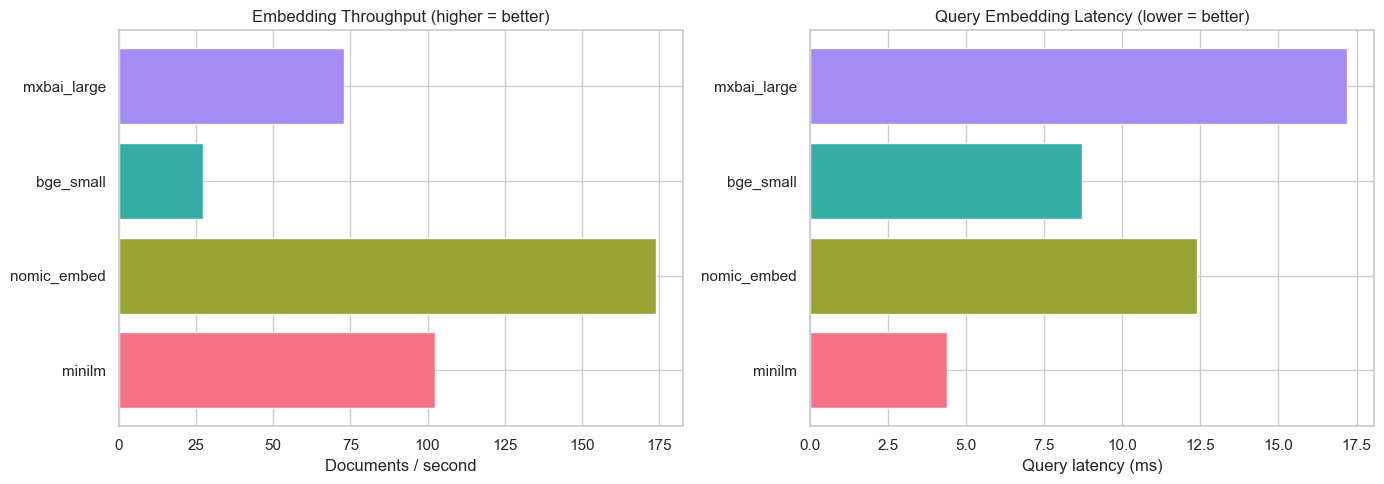

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette("husl", len(bench_df))
model_names = bench_df.index.tolist()

axes[0].barh(model_names, bench_df["docs_per_sec"], color=colors)
axes[0].set_xlabel("Documents / second")
axes[0].set_title("Embedding Throughput (higher = better)")

axes[1].barh(model_names, bench_df["avg_query_ms"], color=colors)
axes[1].set_xlabel("Query latency (ms)")
axes[1].set_title("Query Embedding Latency (lower = better)")

plt.tight_layout()
plt.show()

---
## 4. Semantic Sanity Checks

We test each model with manually crafted pairs that should be similar or dissimilar.
This validates that the model captures meaningful semantic relationships.

In [12]:
SIMILAR_PAIRS = [
    ("How to create a retriever", "Building a document retrieval system"),
    ("Ollama LLM integration", "Using local models with Ollama"),
    ("Text splitting strategies", "How to chunk documents for RAG"),
    ("Vector database storage", "Persisting embeddings in ChromaDB"),
]

DISSIMILAR_PAIRS = [
    ("How to create a retriever", "LangChain license information"),
    ("Token counting", "Vector database persistence"),
    ("Chat model temperature settings", "HTML parsing with BeautifulSoup"),
    ("Prompt template variables", "Python package installation"),
]

print(f"Testing {len(SIMILAR_PAIRS)} similar pairs and {len(DISSIMILAR_PAIRS)} dissimilar pairs.")

Testing 4 similar pairs and 4 dissimilar pairs.


In [13]:
from numpy.linalg import norm

def cosine_sim(a: list[float], b: list[float]) -> float:
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (norm(a) * norm(b) + 1e-10))


sanity_results = {}

for key, m in models.items():
    emb = m["embeddings"]
    sim_scores = []
    dissim_scores = []

    for a, b in SIMILAR_PAIRS:
        va, vb = emb.embed_query(a), emb.embed_query(b)
        sim_scores.append(cosine_sim(va, vb))

    for a, b in DISSIMILAR_PAIRS:
        va, vb = emb.embed_query(a), emb.embed_query(b)
        dissim_scores.append(cosine_sim(va, vb))

    sanity_results[key] = {
        "similar_scores": sim_scores,
        "dissimilar_scores": dissim_scores,
        "avg_similar": float(np.mean(sim_scores)),
        "avg_dissimilar": float(np.mean(dissim_scores)),
        "separation": float(np.mean(sim_scores) - np.mean(dissim_scores)),
    }

# Summary table
sanity_rows = []
for key, r in sanity_results.items():
    sanity_rows.append({
        "model": key,
        "avg_similar": round(r["avg_similar"], 4),
        "avg_dissimilar": round(r["avg_dissimilar"], 4),
        "separation": round(r["separation"], 4),
    })

sanity_df = pd.DataFrame(sanity_rows).set_index("model")
print("Semantic Sanity Check (higher separation = better discrimination):")
display(sanity_df)

Semantic Sanity Check (higher separation = better discrimination):


,avg_similar,avg_dissimilar,separation
model,,,
minilm,0.3971,0.0426,0.3545
nomic_embed,0.5342,0.4339,0.1004
bge_small,0.6850,0.5322,0.1528
mxbai_large,0.6199,0.4133,0.2066


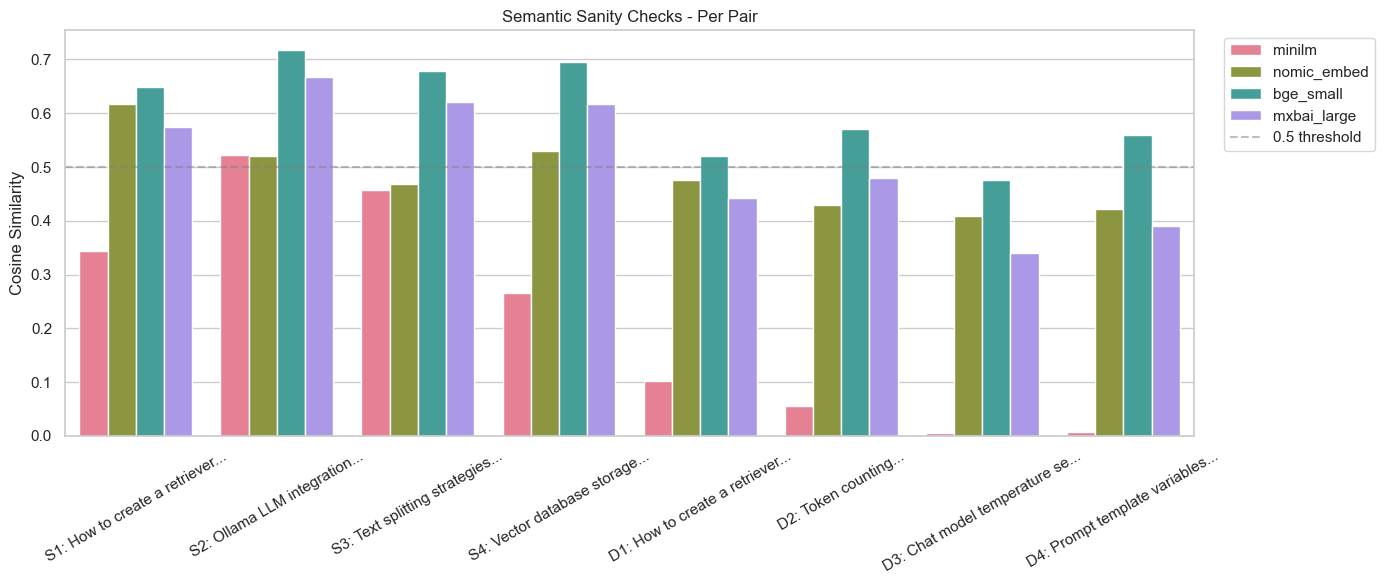

In [14]:
# Detailed per-pair scores
pair_labels_sim = [f"S{i+1}: {a[:25]}..." for i, (a, b) in enumerate(SIMILAR_PAIRS)]
pair_labels_dis = [f"D{i+1}: {a[:25]}..." for i, (a, b) in enumerate(DISSIMILAR_PAIRS)]

detail_data = []
for key, r in sanity_results.items():
    for label, score in zip(pair_labels_sim, r["similar_scores"]):
        detail_data.append({"model": key, "pair": label, "type": "similar", "cosine_sim": score})
    for label, score in zip(pair_labels_dis, r["dissimilar_scores"]):
        detail_data.append({"model": key, "pair": label, "type": "dissimilar", "cosine_sim": score})

detail_df = pd.DataFrame(detail_data)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=detail_df,
    x="pair",
    y="cosine_sim",
    hue="model",
    ax=ax,
    palette="husl",
)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="0.5 threshold")
ax.set_xlabel("")
ax.set_ylabel("Cosine Similarity")
ax.set_title("Semantic Sanity Checks - Per Pair")
ax.tick_params(axis="x", rotation=30)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

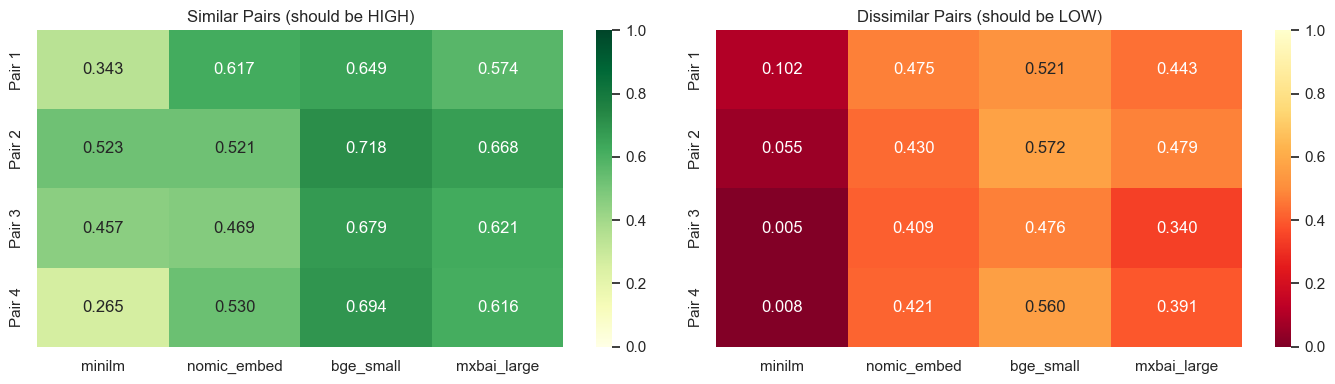

In [15]:
# Separation heatmap: avg_similar - avg_dissimilar per model
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Similar pairs heatmap
sim_matrix = pd.DataFrame(
    {key: r["similar_scores"] for key, r in sanity_results.items()},
    index=[f"Pair {i+1}" for i in range(len(SIMILAR_PAIRS))],
)
sns.heatmap(sim_matrix, annot=True, fmt=".3f", cmap="YlGn", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Similar Pairs (should be HIGH)")

# Dissimilar pairs heatmap
dissim_matrix = pd.DataFrame(
    {key: r["dissimilar_scores"] for key, r in sanity_results.items()},
    index=[f"Pair {i+1}" for i in range(len(DISSIMILAR_PAIRS))],
)
sns.heatmap(dissim_matrix, annot=True, fmt=".3f", cmap="YlOrRd_r", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Dissimilar Pairs (should be LOW)")

plt.tight_layout()
plt.show()

---
## 5. Retrieval Quality Comparison

For each embedding model, we:
1. Index the full corpus into a temporary ChromaDB collection
2. Run benchmark queries
3. Compare retrieval scores and latency

In [16]:
import chromadb
from langchain_chroma import Chroma

PERSIST_DIR = str(PROJECT_ROOT / "vectorstore" / "chroma_db")


def index_with_model(chunks, embeddings, collection_name, batch_size=500):
    """Index chunks into a ChromaDB collection, return (vectorstore, time, skipped)."""
    client = chromadb.PersistentClient(path=PERSIST_DIR)
    try:
        client.delete_collection(collection_name)
    except Exception:
        pass

    vs = Chroma(
        client=client,
        collection_name=collection_name,
        embedding_function=embeddings,
    )

    skipped = 0
    start = time.perf_counter()
    for i in range(0, len(chunks), batch_size):
        batch = chunks[i : i + batch_size]
        try:
            vs.add_documents(batch)
        except Exception as e:
            # Fallback: try one by one
            for doc in batch:
                try:
                    vs.add_documents([doc])
                except Exception:
                    skipped += 1
    elapsed = time.perf_counter() - start

    return vs, elapsed, skipped


# All models index the same pre-filtered chunks
print(f"Indexing {len(chunks)} chunks (pre-filtered to <={MAX_CHARS} chars) per model.\n")

retrieval_results = {}

for key, m in models.items():
    emb = m["embeddings"]
    info = m["info"]
    coll_name = f"emb_eval_{key}"

    print(f"Indexing with {key} ({info.dimensions}d, {info.provider})...", flush=True)
    vs, index_time, skipped = index_with_model(chunks, emb, coll_name)
    indexed_count = vs._collection.count()
    print(f"  Indexed {indexed_count} chunks in {index_time:.1f}s ({skipped} skipped)")

    bench_df = benchmark_queries(vs, BENCH_QUERIES, k=5)
    bench_df["model"] = key

    retrieval_results[key] = {
        "bench_df": bench_df,
        "index_time_s": round(index_time, 1),
        "indexed_count": indexed_count,
        "skipped": skipped,
    }

    print(f"  Avg top score: {bench_df['top_score'].mean():.4f}")
    print(f"  Avg latency:   {bench_df['latency_ms'].mean():.1f} ms")

print("\nAll models indexed and benchmarked.")

Indexing 15577 chunks (pre-filtered to <=1400 chars) per model.

Indexing with minilm (384d, sentence-transformers)...
  Indexed 15577 chunks in 169.7s (0 skipped)
  Avg top score: 0.7616
  Avg latency:   10.6 ms
Indexing with nomic_embed (768d, ollama)...
  Indexed 15577 chunks in 93.6s (0 skipped)
  Avg top score: 0.4673
  Avg latency:   17.9 ms
Indexing with bge_small (384d, sentence-transformers)...
  Indexed 15577 chunks in 494.7s (0 skipped)
  Avg top score: 0.3584
  Avg latency:   16.2 ms
Indexing with mxbai_large (1024d, ollama)...
  Indexed 15566 chunks in 351.5s (11 skipped)
  Avg top score: 0.4030
  Avg latency:   19.8 ms

All models indexed and benchmarked.


In [17]:
# Combined retrieval summary
all_bench = pd.concat([r["bench_df"] for r in retrieval_results.values()], ignore_index=True)

ret_summary = (
    all_bench.groupby("model")
    .agg(
        avg_top_score=("top_score", "mean"),
        avg_avg_score=("avg_score", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
    )
    .round(4)
)

# Add indexing info
for key in ret_summary.index:
    info = models[key]["info"]
    ret_summary.loc[key, "dimensions"] = info.dimensions
    ret_summary.loc[key, "index_time_s"] = retrieval_results[key]["index_time_s"]

ret_summary["dimensions"] = ret_summary["dimensions"].astype(int)

ret_summary = ret_summary[
    ["dimensions", "avg_top_score", "avg_avg_score", "avg_latency_ms", "index_time_s"]
]

print("Retrieval Quality Summary (5 queries, k=5):")
display(ret_summary)

Retrieval Quality Summary (5 queries, k=5):


,dimensions,avg_top_score,avg_avg_score,avg_latency_ms,index_time_s
model,,,,,
bge_small,384,0.3584,0.3822,16.16,494.7
minilm,384,0.7616,0.8429,10.58,169.7
mxbai_large,1024,0.4030,0.4708,19.84,351.5
nomic_embed,768,0.4673,0.5256,17.88,93.6


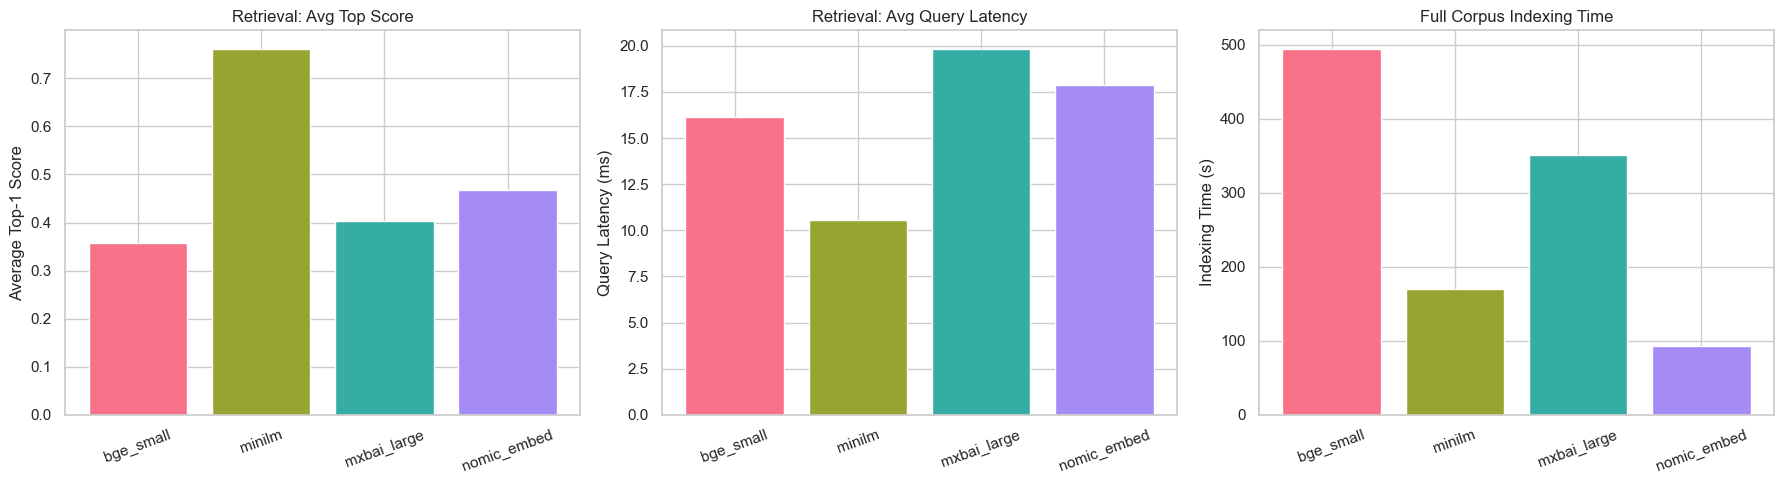

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_order = ret_summary.index.tolist()
colors = sns.color_palette("husl", len(model_order))

# Top score
axes[0].bar(model_order, ret_summary["avg_top_score"], color=colors)
axes[0].set_ylabel("Average Top-1 Score")
axes[0].set_title("Retrieval: Avg Top Score")
axes[0].tick_params(axis="x", rotation=20)

# Latency
axes[1].bar(model_order, ret_summary["avg_latency_ms"], color=colors)
axes[1].set_ylabel("Query Latency (ms)")
axes[1].set_title("Retrieval: Avg Query Latency")
axes[1].tick_params(axis="x", rotation=20)

# Indexing time
axes[2].bar(model_order, ret_summary["index_time_s"], color=colors)
axes[2].set_ylabel("Indexing Time (s)")
axes[2].set_title("Full Corpus Indexing Time")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

---
## 6. Vector Store Size on Disk

We estimate the storage cost per model by measuring the size of the ChromaDB collections
already created in section 5. Since all collections contain the same chunks, the size
difference comes from the embedding dimensions.

In [19]:
# Estimate per-model disk cost from the existing evaluation collections.
# ChromaDB stores all collections in the same sqlite database, so we can't
# measure individual collection sizes directly. Instead, we compute the
# theoretical embedding storage: num_chunks x dimensions x 4 bytes (float32).

disk_results = {}
for key, m in models.items():
    info = m["info"]
    rr = retrieval_results[key]
    n = rr["indexed_count"]

    # Raw embedding bytes (float32 = 4 bytes per dimension)
    embedding_bytes = n * info.dimensions * 4
    # ChromaDB overhead (metadata, indices): roughly 1.3-1.5x raw embeddings
    estimated_mb = (embedding_bytes * 1.4) / (1024 * 1024)

    disk_results[key] = {
        "dimensions": info.dimensions,
        "indexed_chunks": n,
        "embedding_mb": round(embedding_bytes / (1024 * 1024), 1),
        "estimated_total_mb": round(estimated_mb, 1),
    }
    print(f"{key}: {info.dimensions}d x {n} chunks = {embedding_bytes / (1024*1024):.1f} MB embeddings (~{estimated_mb:.1f} MB on disk)")

disk_df = pd.DataFrame(disk_results).T
display(disk_df)

minilm: 384d x 15577 chunks = 22.8 MB embeddings (~31.9 MB on disk)
nomic_embed: 768d x 15577 chunks = 45.6 MB embeddings (~63.9 MB on disk)
bge_small: 384d x 15577 chunks = 22.8 MB embeddings (~31.9 MB on disk)
mxbai_large: 1024d x 15566 chunks = 60.8 MB embeddings (~85.1 MB on disk)


,dimensions,indexed_chunks,embedding_mb,estimated_total_mb
minilm,384.0,15577.0,22.8,31.9
nomic_embed,768.0,15577.0,45.6,63.9
bge_small,384.0,15577.0,22.8,31.9
mxbai_large,1024.0,15566.0,60.8,85.1


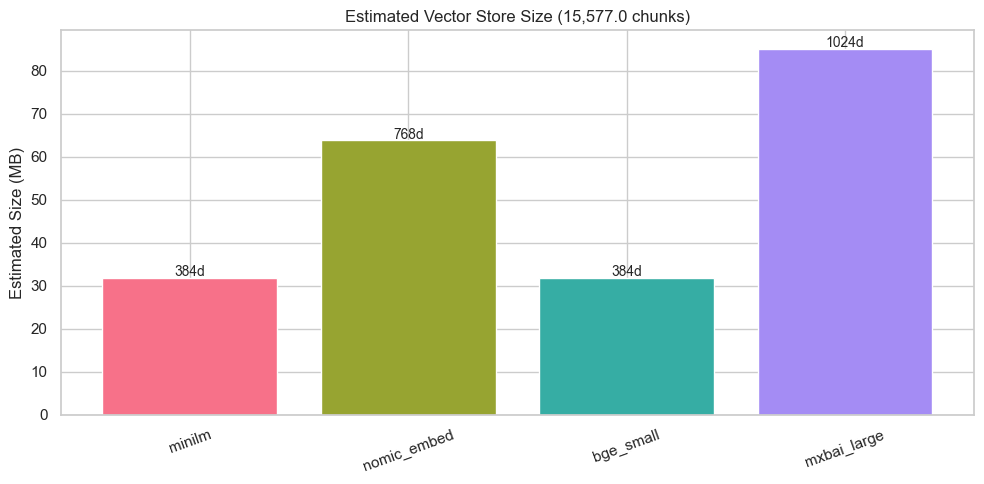

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

disk_models = disk_df.index.tolist()
sizes = disk_df["estimated_total_mb"].values
dims = disk_df["dimensions"].values

bars = ax.bar(disk_models, sizes, color=sns.color_palette("husl", len(disk_models)))

for bar, d in zip(bars, dims):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{int(d)}d",
        ha="center",
        fontsize=10,
    )

ax.set_ylabel("Estimated Size (MB)")
ax.set_title(f"Estimated Vector Store Size ({disk_df['indexed_chunks'].iloc[0]:,} chunks)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

---
## 7. Overall Comparison

Combined view of all metrics to guide model selection.

In [21]:
# Build a combined comparison table
overall_rows = []
for key in models:
    info = models[key]["info"]
    row = {
        "model": key,
        "provider": info.provider,
        "dimensions": info.dimensions,
    }

    # Throughput
    if key in benchmarks:
        bench = benchmarks[key]
        row["corpus_time_s"] = round(bench.embed_corpus_time_s, 2)
        row["docs_per_sec"] = round(bench.num_documents / bench.embed_corpus_time_s, 1) if bench.embed_corpus_time_s > 0 else 0
        row["query_latency_ms"] = round(bench.avg_query_latency_ms, 1)

    # Sanity checks
    if key in sanity_results:
        row["semantic_separation"] = round(sanity_results[key]["separation"], 4)

    # Retrieval
    if key in retrieval_results:
        bench_df = retrieval_results[key]["bench_df"]
        row["avg_top_score"] = round(float(bench_df["top_score"].mean()), 4)
        row["index_time_s"] = retrieval_results[key]["index_time_s"]

    # Disk
    if key in disk_results:
        row["estimated_mb"] = disk_results[key]["estimated_total_mb"]

    overall_rows.append(row)

overall_df = pd.DataFrame(overall_rows).set_index("model")
print("Overall Embedding Model Comparison:")
display(overall_df)

Overall Embedding Model Comparison:


,provider,dimensions,corpus_time_s,docs_per_sec,query_latency_ms,semantic_separation,avg_top_score,index_time_s,estimated_mb
model,,,,,,,,,
minilm,sentence-transformers,384,4.89,102.3,4.4,0.3545,0.7616,169.7,31.9
nomic_embed,ollama,768,2.87,174.1,12.4,0.1004,0.4673,93.6,63.9
bge_small,sentence-transformers,384,18.39,27.2,8.7,0.1528,0.3584,494.7,31.9
mxbai_large,ollama,1024,6.87,72.8,17.2,0.2066,0.4030,351.5,85.1


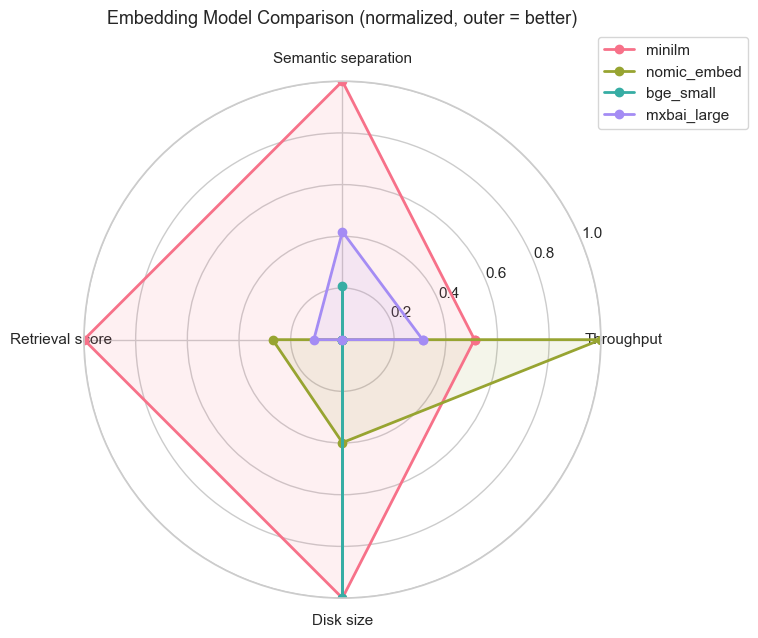

In [22]:
# Normalized radar chart for model comparison
radar_cols = ["docs_per_sec", "semantic_separation", "avg_top_score", "estimated_mb"]
radar_labels = ["Throughput", "Semantic separation", "Retrieval score", "Disk size"]
# For each column, normalize to [0, 1]. For disk size, invert (smaller = better)
radar_data = overall_df[radar_cols].copy()

for col in radar_cols:
    col_min, col_max = radar_data[col].min(), radar_data[col].max()
    if col_max > col_min:
        radar_data[col] = (radar_data[col] - col_min) / (col_max - col_min)
    else:
        radar_data[col] = 0.5

# Invert disk size (lower is better)
radar_data["estimated_mb"] = 1 - radar_data["estimated_mb"]

# Radar plot
angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = sns.color_palette("husl", len(radar_data))

for i, (model_name, row) in enumerate(radar_data.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=model_name, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Embedding Model Comparison (normalized, outer = better)", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

---
## 8. Cleanup Evaluation Collections

In [23]:
client = chromadb.PersistentClient(path=PERSIST_DIR)
existing = [c.name for c in client.list_collections()]

eval_collections = [c for c in existing if c.startswith("emb_eval_")]
print(f"Removing {len(eval_collections)} evaluation collections...")
for name in eval_collections:
    client.delete_collection(name)
    print(f"  Deleted: {name}")

print(f"\nRemaining collections: {[c.name for c in client.list_collections()]}")

Removing 4 evaluation collections...
  Deleted: emb_eval_minilm
  Deleted: emb_eval_bge_small
  Deleted: emb_eval_nomic_embed
  Deleted: emb_eval_mxbai_large

Remaining collections: ['langchain_docs_naive']


---
## 9. Save Results

In [24]:
results_output = {
    "corpus": {
        "total_chunks_before_filter": len(all_chunks),
        "dropped_by_char_filter": dropped_chars,
        "dropped_by_token_validation": token_dropped,
        "chunks_after_filter": len(chunks),
        "max_chars_limit": MAX_CHARS,
    },
    "models": {},
    "benchmark_queries": BENCH_QUERIES,
    "similar_pairs": SIMILAR_PAIRS,
    "dissimilar_pairs": DISSIMILAR_PAIRS,
}

for key in models:
    info = models[key]["info"]
    entry = {
        "provider": info.provider,
        "model_id": info.model_id,
        "dimensions": info.dimensions,
        "max_tokens": info.max_tokens,
        "max_chars": info.max_chars,
        "description": info.description,
    }

    if key in benchmarks:
        bench = benchmarks[key]
        entry["throughput"] = {
            "sample_size": len(sample_texts),
            "embedded_count": bench.num_documents,
            "corpus_time_s": round(bench.embed_corpus_time_s, 2),
            "docs_per_sec": round(bench.num_documents / bench.embed_corpus_time_s, 1) if bench.embed_corpus_time_s > 0 else 0,
            "avg_query_latency_ms": round(bench.avg_query_latency_ms, 1),
        }

    if key in sanity_results:
        sr = sanity_results[key]
        entry["semantic_sanity"] = {
            "avg_similar": round(sr["avg_similar"], 4),
            "avg_dissimilar": round(sr["avg_dissimilar"], 4),
            "separation": round(sr["separation"], 4),
            "similar_scores": [round(s, 4) for s in sr["similar_scores"]],
            "dissimilar_scores": [round(s, 4) for s in sr["dissimilar_scores"]],
        }

    if key in retrieval_results:
        rr = retrieval_results[key]
        bench_df = rr["bench_df"]
        entry["retrieval"] = {
            "avg_top_score": round(float(bench_df["top_score"].mean()), 4),
            "avg_avg_score": round(float(bench_df["avg_score"].mean()), 4),
            "avg_latency_ms": round(float(bench_df["latency_ms"].mean()), 1),
            "index_time_s": rr["index_time_s"],
            "indexed_count": rr["indexed_count"],
        }

    if key in disk_results:
        entry["disk"] = disk_results[key]

    results_output["models"][key] = entry

# Save
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
output_path = results_dir / "embeddings_comparison.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results_output, f, indent=2, ensure_ascii=False)

print(f"Results saved to {output_path}")

Results saved to D:\Astyan\rag-exploration\results\embeddings_comparison.json


---
## 10. Summary & Observations

### Results at a glance

| Model | Throughput | Query latency | Separation | Retrieval top-1 | Indexing | Disk |
|-------|-----------|---------------|------------|-----------------|---------|------|
| **minilm** | 102 docs/s | **4.4 ms** | **0.355** | **0.762** | 170 s | **32 MB** |
| **nomic_embed** | **174 docs/s** | 12.4 ms | 0.100 | 0.467 | **94 s** | 64 MB |
| **bge_small** | 27 docs/s | 8.7 ms | 0.153 | 0.358 | 495 s | 32 MB |
| **mxbai_large** | 73 docs/s | 17.2 ms | 0.207 | 0.403 | 352 s | 85 MB |

### Key findings

**1. Retrieval scores are not comparable across models.**
MiniLM's top-1 score (0.76) does not mean it retrieves better results than Nomic (0.47).
ChromaDB returns L2 distances converted to a similarity score, and models with different
dimensionalities and normalization produce scores on fundamentally different scales.
MiniLM (384d, L2-normalized) produces higher absolute similarities by construction.
The scores are only meaningful for ranking results *within a single model*.

**2. Semantic separation is more informative.**
The sanity check (section 4) tests each model's ability to distinguish related from
unrelated concepts using the same metric (cosine similarity) within each model's own space:

- **MiniLM (0.355)**: highest separation, but driven by very low dissimilar scores (0.04).
  Its embedding space is sparse - almost everything is far apart, so the gap is wide by default.
  This is a consequence of the 256-token context window and L2 normalization, not necessarily
  superior understanding.
- **MxBAI-large (0.207)**: second best. Healthy similar scores (0.62) with contained
  dissimilar scores (0.41). The best balance of absolute quality and discrimination.
- **BGE-small (0.153)**: highest *absolute* similar score (0.685), meaning it captures
  semantic closeness well. But dissimilar pairs also score high (0.53), reducing discrimination.
  Likely due to the instruction prefix being absent in our setup (`query_instruction` is
  not used during `embed_query`).
- **Nomic (0.100)**: poorest separation. Dissimilar pairs score 0.43, close to similar pairs
  at 0.53. The embedding space is compact, making it harder to distinguish topics.

**3. Throughput favors Ollama models.**
Nomic-embed-text leads at 174 docs/s - Ollama batching is efficient even with 768 dimensions.
BGE-small is surprisingly slow (27 docs/s) despite being a small model; sentence-transformers
on CPU with this model is not well optimized. MiniLM is fast (102 docs/s) because the model
itself is tiny (80 MB, 6 layers).

**4. Context window limitations matter.**
MxBAI-embed-large (512 tokens) failed on 11 chunks with high CJK content despite
pre-filtering to 1400 chars. Nomic-embed-text (8192 tokens) had no issues.
MiniLM and BGE truncate silently via sentence-transformers - they don't error but lose
information on long chunks. With `chunk_size=1000`, MiniLM (256 tokens ~ 700 chars)
truncates a significant portion of most chunks.

**5. Disk usage scales linearly with dimensions.**
384d models use ~32 MB, 768d ~64 MB, 1024d ~85 MB for 15.5k chunks.
At this corpus size, storage is not a differentiating factor.

### What we cannot conclude yet

These benchmarks measure **embedding properties in isolation**, not end-to-end RAG quality.
A model with lower retrieval scores here might perform better in practice if its retrieved
chunks lead to better LLM answers. The real test is Phase 9 (RAGAS evaluation) with
human-annotated Q&A pairs measuring faithfulness, answer relevancy, and context precision.

### Provisional recommendation

**nomic-embed-text** for Phase 4 onwards:
- Fastest indexing (94s for 15.5k chunks), critical for rapid iteration
- Largest context window (8192 tokens), no truncation or errors
- Native Ollama integration (same stack as Mistral 7B, simpler deployment)
- Acceptable semantic quality (separation is low but compensated by other pipeline stages)

MxBAI-embed-large is the quality alternative if indexing speed is not a concern and
chunks are kept short. MiniLM is a strong option if query latency is critical (4.4 ms).

This choice will be revisited after Phase 9 with end-to-end evaluation metrics.

### Next: Phase 4 - Retrieval Methods (`04_retrieval_methods.ipynb`)

We will compare retrieval strategies (dense, sparse BM25, hybrid, MMR) using
nomic-embed-text as the embedding model.